In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#import gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import random
import pdb
import plotly.express as px
import plotly.graph_objects as go
import pickle
import scipy.io
from matplotlib.font_manager import FontProperties
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm import tqdm
import matplotlib.animation as animation
import glob
from natsort import natsorted
from PIL import Image
from scipy.special import jv
from scipy import special

# Simulation of BLER vs S(I)NR using Monte Carlo simulations

Done awgn
Done rayleigh
Done rician


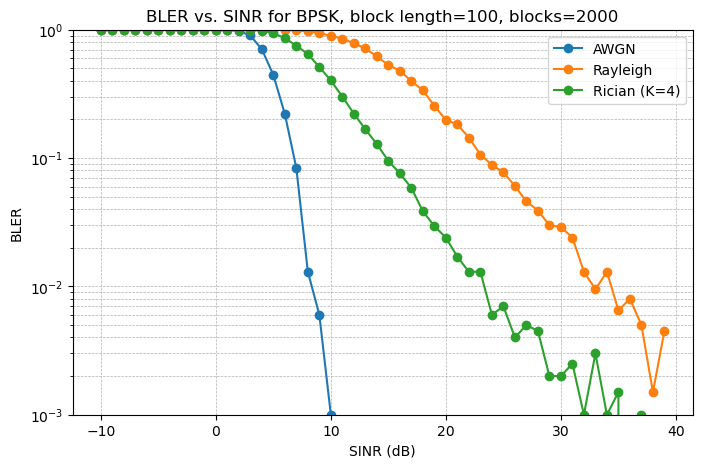

In [166]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rice

def simulate_bler(snr_db, channel, n_blocks=2000, blk_len=100, K=10):
    """
    Simulate BLER for a given SNR over the specified channel.
    
    Parameters:
    - snr_db: scalar SNR in dB
    - channel: 'awgn', 'rayleigh' or 'rician'
    - n_blocks: number of blocks to simulate
    - blk_len: bits per block
    - K: Rician K-factor (linear)
    
    Returns:
    - bler: estimated block error rate
    """
    snr_lin = 10**(snr_db/10)
    sigma = np.sqrt(1/(2*snr_lin))
    n_err_blocks = 0
    
    for _ in range(n_blocks):
        # generate bits and BPSK symbols
        bits = np.random.randint(0, 2, blk_len)
        symbols = 2*bits - 1
        
        # fading gain
        if channel == 'awgn':
            h = 1.0
        elif channel == 'rayleigh':
            h = (np.random.normal(size=blk_len) + 1j*np.random.normal(size=blk_len))/np.sqrt(2)
        elif channel == 'rician':
            # generate per-symbol Rician fading
            # non-centrality = sqrt(K/(K+1)), scatter variance = 1/(K+1)
            nu = np.sqrt(K/(K+1))
            sigma_f = np.sqrt(1/(2*(K+1)))
            h = (nu + sigma_f*np.random.normal(size=blk_len) +
                 1j*(sigma_f*np.random.normal(size=blk_len)))
        else:
            raise ValueError("Unsupported channel type")
        
        # transmit over channel + noise
        noise = sigma*(np.random.normal(size=blk_len) + 1j*np.random.normal(size=blk_len))
        rx = h*symbols + noise
        
        # equalize (divide by h) for fading channels
        rx_eq = rx / h
        
        # hard decision
        bits_hat = (rx_eq.real >= 0).astype(int)
        
        if np.any(bits_hat != bits):
            n_err_blocks += 1
    
    return n_err_blocks / n_blocks

# simulation parameters
snr_dbs = np.arange(-10, 40,1)
channels = ['awgn', 'rayleigh', 'rician']
K_factor = 4      # Rician K-factor
n_blocks = 2000
blk_len = 100

# run simulations
bler = {ch: [] for ch in channels}
for ch in channels:
    for snr in snr_dbs:
        bler[ch].append(simulate_bler(snr, ch, n_blocks, blk_len, K=K_factor))
    print(f"Done {ch}")

# plot
plt.figure(figsize=(8,5))
for ch in channels:
    lbl = ch.upper() if ch=='awgn' else ch.capitalize()
    if ch=='rician':
        lbl += f" (K={K_factor})"
    plt.semilogy(snr_dbs, bler[ch], marker='o', label=lbl)

plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlabel("SINR (dB)")
plt.ylabel("BLER")
plt.title(f"BLER vs. SINR for BPSK, block length={blk_len}, blocks={n_blocks}")
plt.legend()
plt.ylim(1e-3, 1)
plt.show()


# BLER for different types of fading for our case

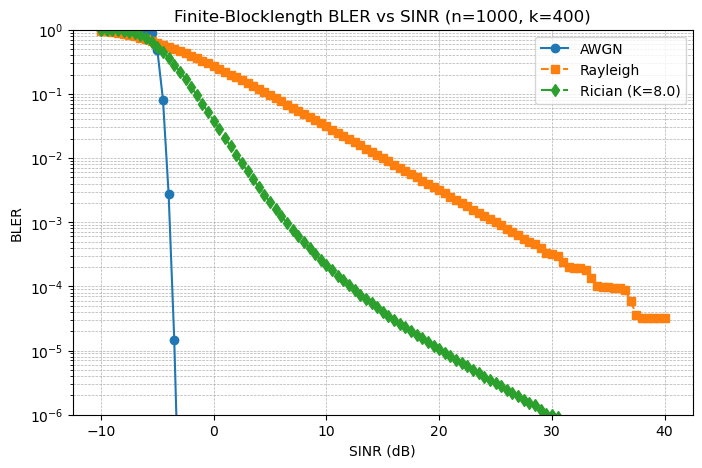

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, i0

# Parameters
n = 1000       # block length
k = 400        # message bits
rate = k / n
K_rician = 8.0
snr_dbs = np.linspace(-10, 40, 101)

# Normal approximation for AWGN BLER
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))

def Pe_finite_awgn(snr_db):
    gamma = 10**(snr_db / 10)
    C = np.log2(1 + gamma)
    V = (gamma * (gamma + 2) / (gamma + 1)**2) * (np.log2(np.e))**2
    numerator = n * C - k + 0.5 * np.log2(n)
    denominator = np.sqrt(n * V)
    return qfunc(numerator / denominator)

# Outage-style BLER via fading integration
def bler_fading(snr_db, fading='rayleigh', K=4.0, r_max=8, n_r=2000):
    gamma_bar = 10**(snr_db / 10)
    r = np.linspace(0, r_max, n_r)
    if fading == 'rayleigh':
        pdf = 2 * r * np.exp(-r**2)
    elif fading == 'rician':
        pdf = 2 * r * (K + 1) * np.exp(-K - (K + 1) * r**2) * i0(2 * r * np.sqrt(K * (K + 1)))
    else:
        raise ValueError("Unsupported fading type")
    # Normalize PDF
    pdf /= np.trapz(pdf, r)
    # Instantaneous SNR = gamma_bar * r^2
    gamma_inst = gamma_bar * (r**2)
    # Compute BLER at each r via normal approximation
    Pe_inst = np.array([Pe_finite_awgn(10 * np.log10(g)) if g > 0 else 1.0 for g in gamma_inst])
    # Average BLER over fading
    return np.trapz(Pe_inst * pdf, r)

# Compute BLER curves
bler_awgn = np.array([Pe_finite_awgn(s) for s in snr_dbs])
bler_rayleigh = np.array([bler_fading(s, 'rayleigh') for s in snr_dbs])
bler_rician = np.array([bler_fading(s, 'rician', K=K_rician) for s in snr_dbs])

# Plotting
plt.figure(figsize=(8, 5))
plt.semilogy(snr_dbs, bler_awgn, 'o-', label='AWGN')
plt.semilogy(snr_dbs, bler_rayleigh, 's--', label='Rayleigh')
plt.semilogy(snr_dbs, bler_rician, 'd-.', label=f'Rician (K={K_rician})')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel("SINR (dB)")
plt.ylabel("BLER")
plt.title("Finite-Blocklength BLER vs SINR (n=1000, k=400)")
plt.ylim(1e-6, 1)
plt.legend()
plt.show()


# Approximation to the above theoretical expression 

AWGN threshold γ_th ≈ -2.824 dB


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


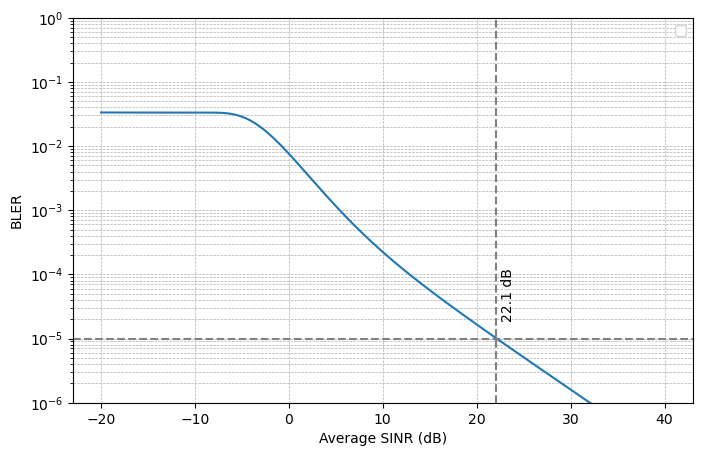

Approximate crossing at ≈ 22.1 dB


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

# 1) Parameters
k = 400
q = 1000
gap_db = 1.0
K = 4.0
Ntones = 30
target = 1e-5

mp.mp.dps = 20  # precision for mpmath

# 2) Finite-block AWGN error via the normal approximation
def P_e_awgn(sinr_db):
    γ = 10**((sinr_db - gap_db)/10)
    C = mp.log(1 + γ, 2)
    V = ((γ**2 + γ)/(1 + γ)**2)*(mp.log(mp.e, 2)**2)
    z = (2*q*C - 2*k + mp.log(q, 2)) / (2*mp.sqrt(q*V))
    return 0.5 * mp.erfc(z/mp.sqrt(2))

# 3) Find the AWGN threshold γ_th_db where P_e_awgn = target
def find_gamma_th():
    lo, hi = -6, 2
    f_lo, f_hi = P_e_awgn(lo) - target, P_e_awgn(hi) - target
    for _ in range(50):
        mid = 0.5*(lo + hi)
        f_mid = P_e_awgn(mid) - target
        if f_lo * f_mid <= 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid
    return 0.5*(lo + hi)

γ_th_db = find_gamma_th()
γ_th_lin = 10**(γ_th_db/10)
print(f"AWGN threshold γ_th ≈ {γ_th_db:.3f} dB")

# 4) Marcum-Q1 via mpmath quadrature
def Q1(a, b):
    integrand = lambda x: x * mp.e**(-(x**2 + a**2)/2) * mp.besseli(0, a*x)
    return mp.quad(integrand, [b, mp.inf])

a = mp.sqrt(2*K)

# 5) Approximate outage‐averaged BLER (divide by Ntones)
def bler_approx(avg_db):
    γ_bar = 10**(avg_db/10)
    b = mp.sqrt(2*(K+1)*γ_th_lin/γ_bar)
    return (1 - Q1(a, b)) / Ntones

# 6) Sweep and plot
sinr_dbs = np.linspace(-20, 40, 601)
bler_vals = [float(bler_approx(db)) for db in sinr_dbs]
cross_idx = np.argmin(np.abs(np.array(bler_vals) - target))
cross_sinr = sinr_dbs[cross_idx]

plt.figure(figsize=(8,5))
plt.semilogy(sinr_dbs, bler_vals)
plt.axhline(target, ls='--', color='grey')
plt.axvline(cross_sinr, ls='--', color='grey')
plt.text(cross_sinr+0.5, target*2, f'{cross_sinr:.1f} dB', rotation=90)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlabel('Average SINR (dB)')
plt.ylabel('BLER')
#plt.title('Approximate Outage‐Averaged BLER vs. SINR\n(n=1000, k=400, K=4, Ntones=30)')
plt.ylim(1e-6, 1)
plt.legend()
plt.show()

print(f"Approximate crossing at ≈ {cross_sinr:.1f} dB")


# Using surrogate BLER function only for reward purposes

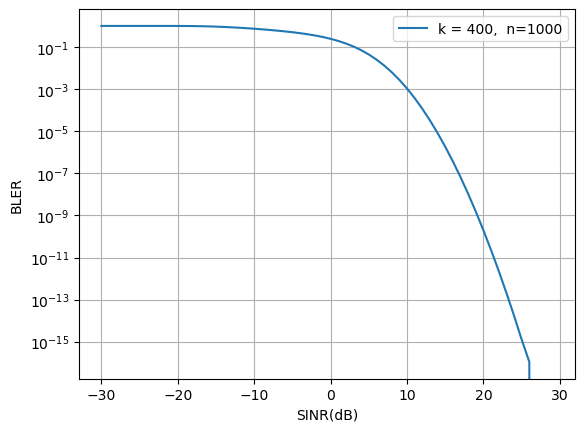

In [9]:
'''
This is done only for reward purposes where k and n scales are such that the variation of SINR directly affects the 
BLER. However, for actual evaluation of policies the BLER expression for Rician fading is used. Also it is important to note that 
just using this expression for reward function also yields similar performances.
''';
def bler(k, n, sinr_db):
    #k,n,P_o = 400/1500,1, 1e-5
    k_n, n_n = k/n, n/n
    sinr_lin = 10 ** (np.array(sinr_db) / 10)
    V_gamma = 1 - (1/(1 + sinr_lin)**2)
    C_gamma = np.log2(1 + sinr_lin)
    Q_term = (2*n/n*C_gamma - 2*k_n + np.log2(n/n))/(2*np.sqrt(n/n*V_gamma))
    #Q_term = (np.sqrt(n/V_gamma))*(C_gamma -(k/n))
    P_e = 0.5-0.5*special.erf(Q_term/np.sqrt(2))
    return P_e

#P_e1 = bler(k = 0.4, n = 1, p_o = 1e-5)
sinr_db = np.arange(-30,30,1)
P_e = bler(k = 400, n = 1000, sinr_db = sinr_db)

plt.semilogy(sinr_db, P_e, label = 'k = {},  n={}'.format(400,1000))

plt.xlabel('SINR(dB)')
plt.ylabel('BLER')
plt.legend()
plt.grid()